# VIX Volatility Forecasting Notebook

This notebook develops and validates a short-horizon forecasting pipeline for the CBOE Volatility Index (VIX), with a target forecast window of **Apr 20-24, 2026**.

The workflow combines a mean model (ARIMA) with a volatility model (GJR-GARCH), then reports point forecasts and 95% prediction intervals.

In [ ]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
from scipy.optimize import minimize
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, adfuller, kpss, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from tqdm import tqdm

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

### Reusable Statistical Diagnostics

This section defines helper functions used throughout the notebook for:
- unit-root checks (ADF and KPSS),
- autocorrelation diagnostics (ACF and PACF), and
- heteroskedasticity tests (ARCH-LM).

In [ ]:
def unit_root_summary(y, name="series"):
    rows = []
    for reg, label in [("c", "constant"), ("ct", "constant + trend")]:
        try:
            adf_res = adfuller(y, regression=reg, autolag="AIC")
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": adf_res[0],
                "pvalue": adf_res[1],
                "usedlag": adf_res[2]
            })
        except Exception as e:
            rows.append({
                "series": name,
                "test": f"ADF ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
        try:
            kpss_res = kpss(y, regression=reg, nlags="auto")
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": kpss_res[0],
                "pvalue": kpss_res[1],
                "usedlag": kpss_res[2]
            })
        except Exception:
            rows.append({
                "series": name,
                "test": f"KPSS ({label})",
                "stat": np.nan,
                "pvalue": np.nan,
                "usedlag": np.nan
            })
    return pd.DataFrame(rows)

def arch_lm_table(y, nlags=4):
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, nlags=nlags)
    return pd.DataFrame({
        "LM stat": [lm_stat],
        "LM p-value": [lm_pvalue],
        "F stat": [f_stat],
        "F p-value": [f_pvalue],
        "lags": [nlags]
    })

def plot_hist_density_qq(y, title_prefix="Series"):
    yy = np.asarray(y)
    mu, sig = yy.mean(), yy.std(ddof=0)
    x = np.linspace(mu - 4*sig, mu + 4*sig, 400)

    plt.figure(figsize=(10,5))
    plt.hist(yy, bins=30, density=True, alpha=0.5, label="Histogram")
    kde = stats.gaussian_kde(yy)
    plt.plot(x, kde(x), linewidth=2, label="Kernel density")
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=sig), linewidth=2, label="Normal density")
    plt.title(f"{title_prefix}: histogram, kernel density, and normal density")
    plt.tight_layout()
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,5))
    stats.probplot(yy, dist="norm", plot=plt)
    plt.title(f"{title_prefix}: Normal Q-Q plot")
    plt.tight_layout()
    plt.show()

def get_param(fit, *candidates, default=np.nan):
    names = list(getattr(fit, "param_names", []))
    params = np.asarray(fit.params)
    for c in candidates:
        if c in names:
            return float(params[names.index(c)])
    return default

def fit_arch1(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea = np.exp(u[1])
        alpha = ea / (1 + ea)
        return omega, alpha
    def nll(u):
        omega, alpha = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    res = minimize(nll, [np.log(var0*0.1), np.log(0.1/0.9)], method="L-BFGS-B")
    omega, alpha = unpack(res.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2
    ll = -nll(res.x)
    return {
        "omega": omega, "alpha": alpha, "loglik": ll, "aic": 2*2 - 2*ll,
        "bic": np.log(n)*2 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": res.success
    }

def fit_garch11(y):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    n = len(y)
    var0 = np.var(y)
    def unpack(u):
        omega = np.exp(u[0])
        ea, eb = np.exp(u[1]), np.exp(u[2])
        s = 1 + ea + eb
        alpha = ea / s
        beta = eb / s
        return omega, alpha, beta
    def nll(u):
        omega, alpha, beta = unpack(u)
        h = np.empty(n)
        h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
        for t in range(1, n):
            h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
        return 0.5 * np.sum(np.log(h) + y**2 / h)
    starts = [
        [np.log(var0*0.01), np.log(0.07/0.03), np.log(0.90/0.03)],
        [np.log(var0*0.10), np.log(0.05/0.05), np.log(0.90/0.05)],
        [np.log(var0*0.01), np.log(0.10/0.10), np.log(0.80/0.10)],
    ]
    best = None
    for s in starts:
        r = minimize(nll, s, method="L-BFGS-B")
        if best is None or r.fun < best.fun:
            best = r
    omega, alpha, beta = unpack(best.x)
    h = np.empty(n)
    h[0] = max(var0, omega / max(1e-6, 1-alpha-beta))
    for t in range(1, n):
        h[t] = omega + alpha * y[t-1]**2 + beta * h[t-1]
    ll = -nll(best.x)
    return {
        "omega": omega, "alpha": alpha, "beta": beta, "loglik": ll, "aic": 2*3 - 2*ll,
        "bic": np.log(n)*3 - 2*ll, "h": h, "resid": y/np.sqrt(h), "centered_y": y,
        "success": best.success
    }

def garch_forecast_path(fit_dict, y, steps=10):
    y = np.asarray(y, dtype=float)
    y = y - np.mean(y)
    omega = fit_dict["omega"]
    alpha = fit_dict.get("alpha", 0.0)
    beta = fit_dict.get("beta", 0.0)
    h_last = fit_dict["h"][-1]
    y_last = y[-1]
    out = np.empty(steps)
    out[0] = omega + alpha * y_last**2 + beta * h_last
    for k in range(1, steps):
        out[k] = omega + (alpha + beta) * out[k-1]
    return out

In [ ]:
# Forecast horizon settings
FORECAST_START = "2026-04-20"
FORECAST_END = "2026-04-24"

TARGET_LABEL = "VIX"

FORECAST_DATES = pd.date_range(FORECAST_START, FORECAST_END, freq="D")
H = len(FORECAST_DATES)

In [ ]:
def to_2col_array(ci):
    """Return conf_int as a (h,2) numpy array, robust to DataFrame/ndarray."""
    return np.asarray(ci)

def plot_series(y, title, xlabel="t", ylabel="value"):
    plt.figure(figsize=(10,5))
    x_axis = y.index if hasattr(y, "index") else np.arange(1, len(y)+1)
    y_vals = y.values if hasattr(y, "values") else y
    plt.plot(x_axis, y_vals, linewidth=1)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_acf_pacf(y, nlags=24, pacf_method="ywm"):
    yy = np.asarray(y)
    n = len(yy)
    nlags = min(nlags, n//2 - 1)
    nlags = max(nlags, 1)

    r = acf(yy, nlags=nlags, fft=False)
    p = pacf(yy, nlags=nlags, method=pacf_method)

    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample ACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), p, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"Sample PACF (nlags={nlags}), bands = ±1.96/√n (n={n})")
    plt.tight_layout()
    plt.show()

    return r, p

def residual_report(fit, lags=(8,12,16,20)):
    resid = np.asarray(fit.resid)
    lb = acorr_ljungbox(resid, lags=list(lags), return_df=True)
    return resid, lb

def plot_resid_acf(resid, nlags=24, title="Residual ACF"):
    rr = np.asarray(resid)
    n = len(rr)
    nlags = min(nlags, n - 1)

    r = acf(rr, nlags=nlags, fft=False)
    band = 1.96 / np.sqrt(n)

    plt.figure(figsize=(10,5))
    plt.stem(range(nlags+1), r, basefmt=" ")
    plt.axhline(0, linewidth=1)
    plt.axhline(band, linestyle="--", linewidth=1)
    plt.axhline(-band, linestyle="--", linewidth=1)
    plt.title(f"{title} (bands = ±1.96/√n, n={n})")
    plt.tight_layout()
    plt.show()

def forecast_table_and_plot(fit, steps, y, title_prefix="Forecast"):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci_arr = to_2col_array(fc.conf_int(alpha=0.05))

    n = len(y)
    idx = np.arange(n+1, n+steps+1)
    fc_df = pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci_arr[:,0],
        "upper_95": ci_arr[:,1],
    }, index=idx)

    plt.figure(figsize=(10,5))
    plt.plot(np.arange(1, n+1), np.asarray(y), label="observed", linewidth=1)
    t_fc = np.arange(n+1, n+steps+1)
    plt.plot(t_fc, mean_fc, label="forecast", linewidth=2)
    plt.fill_between(t_fc, ci_arr[:,0], ci_arr[:,1], alpha=0.2, label="95% PI")
    plt.title(f"{title_prefix}")
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

    return fc_df

def ets_benchmarks(y, seasonal_periods=None, seasonal=None):
    yy = pd.Series(y).astype(float)
    ses = ExponentialSmoothing(yy, trend=None, seasonal=None).fit(optimized=True)
    holt = ExponentialSmoothing(yy, trend="add", seasonal=None, damped_trend=False).fit(optimized=True)
    hw = None
    if seasonal_periods is not None and seasonal is not None:
        hw = ExponentialSmoothing(yy, trend="add", seasonal=seasonal,
                                  seasonal_periods=seasonal_periods).fit(optimized=True)
    return ses, holt, hw

def plot_ets_forecasts(y, steps, ses, holt, hw=None, title="ETS benchmarks"):
    yy = np.asarray(y)
    n = len(yy)
    t = np.arange(1, n+1)
    t_fc = np.arange(n+1, n+steps+1)

    f_ses = ses.forecast(steps)
    f_holt = holt.forecast(steps)

    plt.figure(figsize=(10,5))
    plt.plot(t, yy, label="observed", linewidth=1)
    plt.plot(t_fc, f_ses, label="SES", linewidth=2)
    plt.plot(t_fc, f_holt, label="Holt", linewidth=2)
    if hw is not None:
        f_hw = hw.forecast(steps)
        plt.plot(t_fc, f_hw, label="Holt-Winters", linewidth=2)

    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

def forecast_df(fit, steps, n_obs):
    fc = fit.get_forecast(steps=steps)
    mean_fc = np.asarray(fc.predicted_mean)
    ci = np.asarray(fc.conf_int(alpha=0.05))
    idx = np.arange(n_obs+1, n_obs+steps+1)
    return pd.DataFrame({
        "forecast": mean_fc,
        "lower_95": ci[:,0],
        "upper_95": ci[:,1]
    }, index=idx)

def forecast_plot(y, fc_df, title="Forecast with 95% PI"):
    y = np.asarray(y)
    n = len(y)
    t = np.arange(1, n+1)
    t_fc = fc_df.index.values
    plt.figure(figsize=(10,5))
    plt.plot(t, y, label="observed", linewidth=1.5)
    plt.plot(t_fc, fc_df["forecast"].values, label="forecast", linewidth=2)
    plt.fill_between(t_fc, fc_df["lower_95"].values, fc_df["upper_95"].values, alpha=0.2, label="95% PI")
    plt.title(title)
    plt.xlabel("t")
    plt.tight_layout()
    plt.legend()
    plt.show()

In [ ]:
def _default_range(days=3 * 365):
    end = datetime.now(timezone.utc).date()
    start = end - timedelta(days=days)
    return start.isoformat(), end.isoformat()


def _inclusive_end_for_yf(end_str):
    end_dt = datetime.strptime(end_str, "%Y-%m-%d").date()
    inclusive_plus = end_dt + timedelta(days=1)
    return inclusive_plus.isoformat()


def get_vix_df(start: str = None, end: str = None, days: int = 365, symbol: str = "^VIX") -> pd.DataFrame:
    """Fetch VIX adjusted close and align to a daily calendar."""
    if start is None or end is None:
        default_start, default_end = _default_range(days)
        start = start or default_start
        end = end or default_end

    try:
        datetime.strptime(start, "%Y-%m-%d")
        datetime.strptime(end, "%Y-%m-%d")
    except ValueError as exc:
        raise ValueError("start and end must be in YYYY-MM-DD format") from exc

    yf_end = _inclusive_end_for_yf(end)
    date_index = pd.date_range(start=start, end=end, freq="D")
    df = yf.download(symbol, start=start, end=yf_end, auto_adjust=True, progress=False)

    if df is None or df.empty:
        out = pd.DataFrame({"date": date_index, "VIX": np.nan})
        out["date"] = pd.to_datetime(out["date"])
        return out

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [
            "_".join([str(c) for c in col if c is not None]).strip()
            for col in df.columns.values
        ]

    if "Close" in df.columns:
        series = df[["Close"]].rename(columns={"Close": "VIX"})
    elif "Adj Close" in df.columns:
        series = df[["Adj Close"]].rename(columns={"Adj Close": "VIX"})
    else:
        numeric_cols = df.select_dtypes(include="number").columns
        if len(numeric_cols) == 0:
            out = pd.DataFrame({"date": date_index, "VIX": np.nan})
            out["date"] = pd.to_datetime(out["date"])
            return out
        first_col = numeric_cols[0]
        series = df[[first_col]].rename(columns={first_col: "VIX"})

    series.index = pd.to_datetime(series.index).normalize()
    aligned = series.reindex(date_index)
    aligned.index.name = "date"
    aligned = aligned.reset_index()

    aligned["date"] = pd.to_datetime(aligned["date"])
    aligned["VIX"] = aligned["VIX"].astype(float)

    return aligned

In [ ]:
df_live = get_vix_df(days=365 * 5)
df_live.head(10)

,date,VIX
0,2021-04-18,NaN
1,2021-04-19,17.2900
2,2021-04-20,18.6800
3,2021-04-21,17.5000
4,2021-04-22,18.7100
5,2021-04-23,17.3300
6,2021-04-24,NaN
7,2021-04-25,NaN
8,2021-04-26,17.6400
9,2021-04-27,17.5600


In [ ]:
def process_live_df(df: pd.DataFrame, date_col: str, target_col: str) -> pd.Series:
    # 1. Clean and convert types
    out = df[[date_col, target_col]].copy()
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out[target_col] = pd.to_numeric(out[target_col], errors='coerce')

    # 2. Drop invalid rows and sort chronologically
    out = out.dropna(subset=[date_col]).sort_values(date_col)

    # 3. Set date as index and force a Daily frequency
    s = out.set_index(date_col)[target_col].asfreq('D')

    s = s.interpolate(method='time').ffill().bfill()

    return s

In [ ]:
# Keep a truncated sample to reproduce report-era training behavior.
full_series = process_live_df(df_live, "date", TARGET_LABEL)
series = full_series[:-30]

In [ ]:
n_series = len(series)
print("Number of observations:", n_series)
print("First 10 observations:", series[:10])
print("Last 10 observations:", series[-10:])

Number of observations: 1796
First 10 observations: date
2021-04-18   17.2900
2021-04-19   17.2900
2021-04-20   18.6800
2021-04-21   17.5000
2021-04-22   18.7100
2021-04-23   17.3300
2021-04-24   17.4333
2021-04-25   17.5367
2021-04-26   17.6400
2021-04-27   17.5600
Freq: D, Name: VIX, dtype: float64
Last 10 observations: date
2026-03-09   25.5000
2026-03-10   24.9300
2026-03-11   24.2300
2026-03-12   27.2900
2026-03-13   27.1900
2026-03-14   25.9633
2026-03-15   24.7367
2026-03-16   23.5100
2026-03-17   22.3700
2026-03-18   25.0900
Freq: D, Name: VIX, dtype: float64


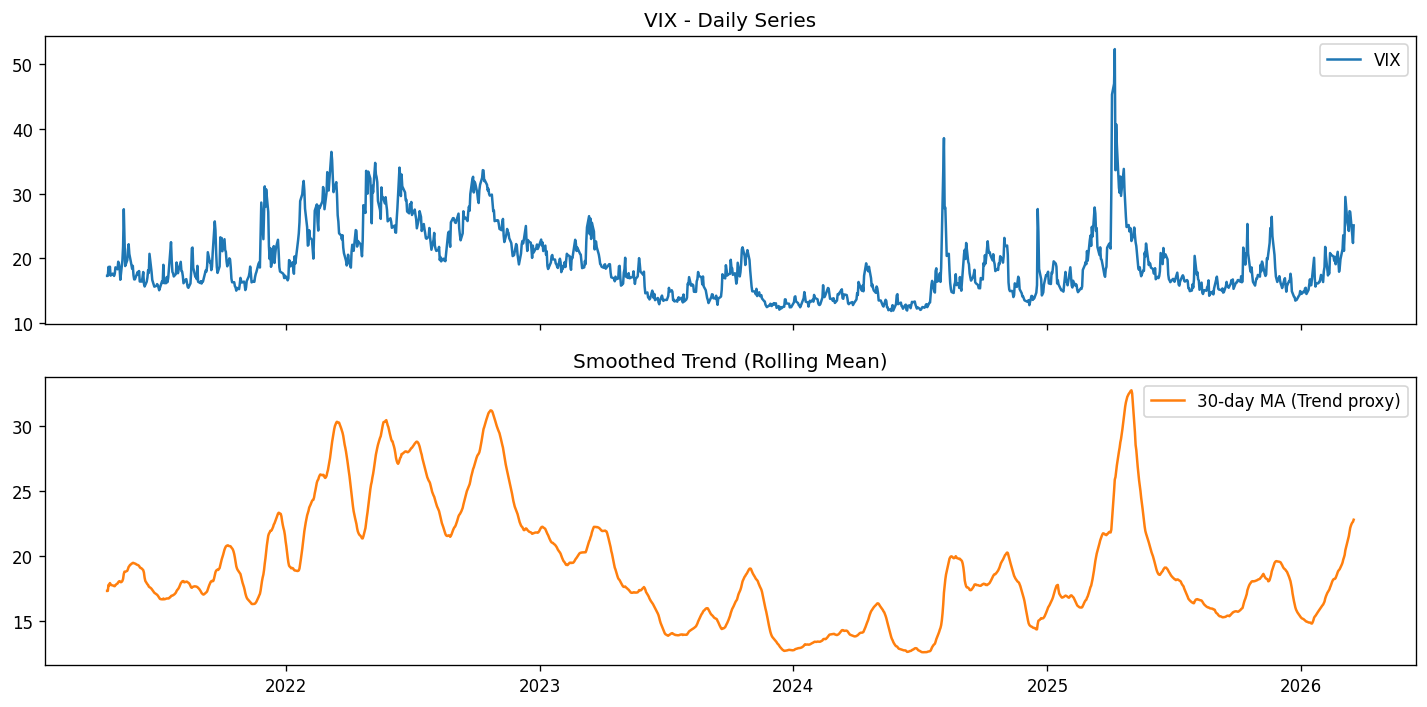

In [ ]:
# -----------------------------
# VISUALIZATION
# -----------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(series.index, series.values, label=TARGET_LABEL)
axes[0].set_title(f'{TARGET_LABEL} - Daily Series')
axes[0].legend()

roll = series.rolling(30, min_periods=1).mean()
axes[1].plot(series.index, roll.values, color='tab:orange', label='30-day MA (Trend proxy)')
axes[1].set_title('Smoothed Trend (Rolling Mean)')
axes[1].legend()

plt.tight_layout()
plt.show()

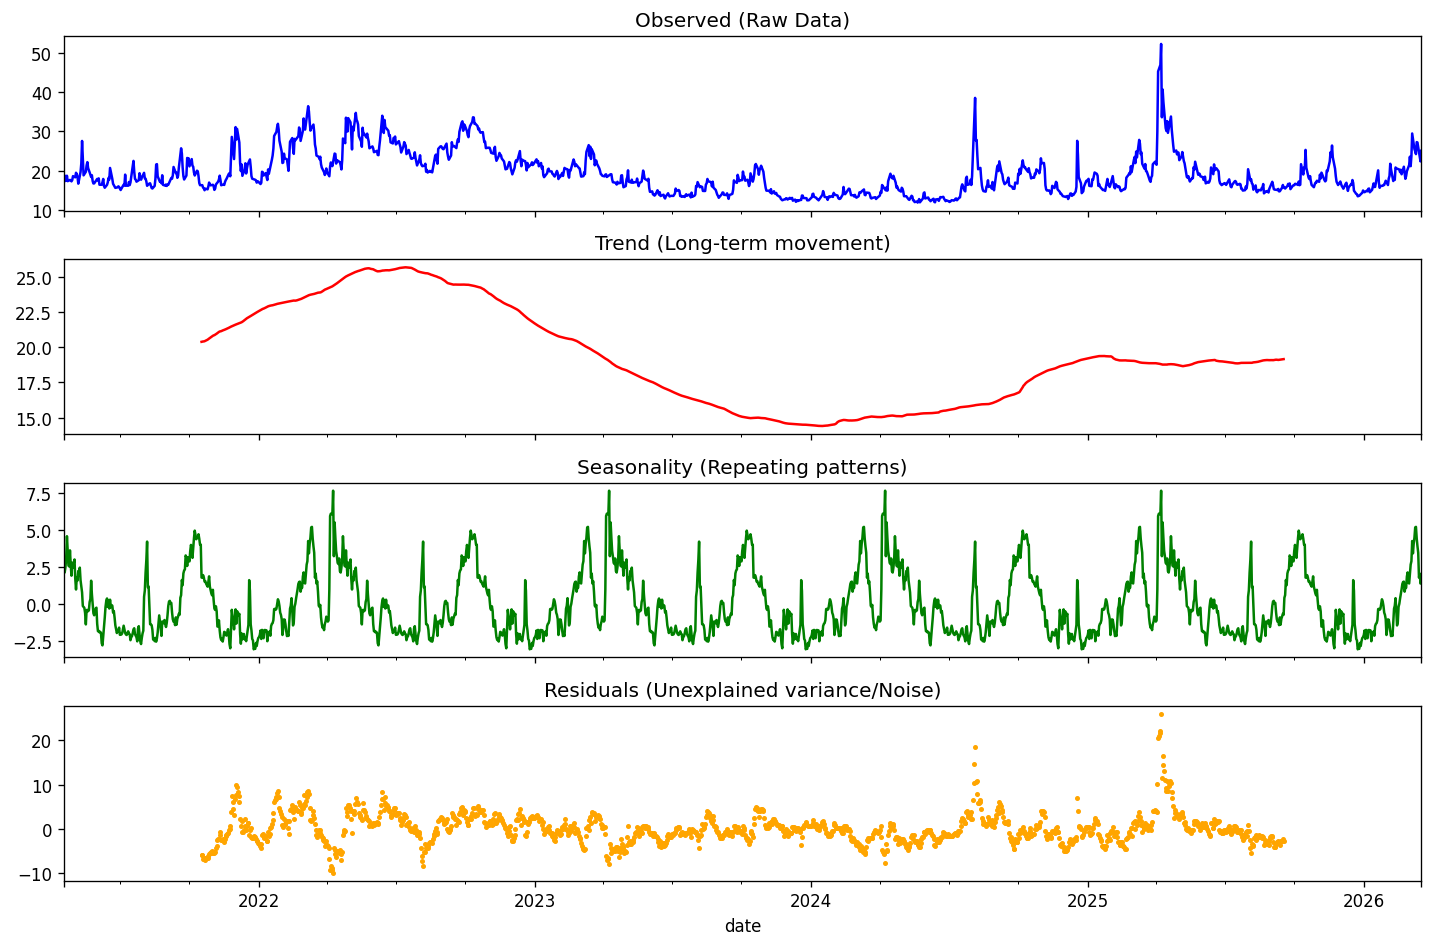

In [ ]:
# -----------------------------
# PLOT TREND/SEASONALITY/RESIDUALS
# -----------------------------

result = seasonal_decompose(series, model='additive', period=int(365))

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

result.observed.plot(ax=ax1, color='blue')
ax1.set_title('Observed (Raw Data)')

# Trend: The long-term progression of the series, stripping away short-term fluctuations.
result.trend.plot(ax=ax2, color='red')
ax2.set_title('Trend (Long-term movement)')

# Seasonal: Repeating patterns that occur over a fixed period (e.g., annual cycles).
result.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Seasonality (Repeating patterns)')

# Residual: What’s left after removing trend and seasonality; the "noise" or "shocks."
result.resid.plot(ax=ax4, color='orange', style='o', markersize=2)
ax4.set_title('Residuals (Unexplained variance/Noise)')

plt.tight_layout()
plt.show()

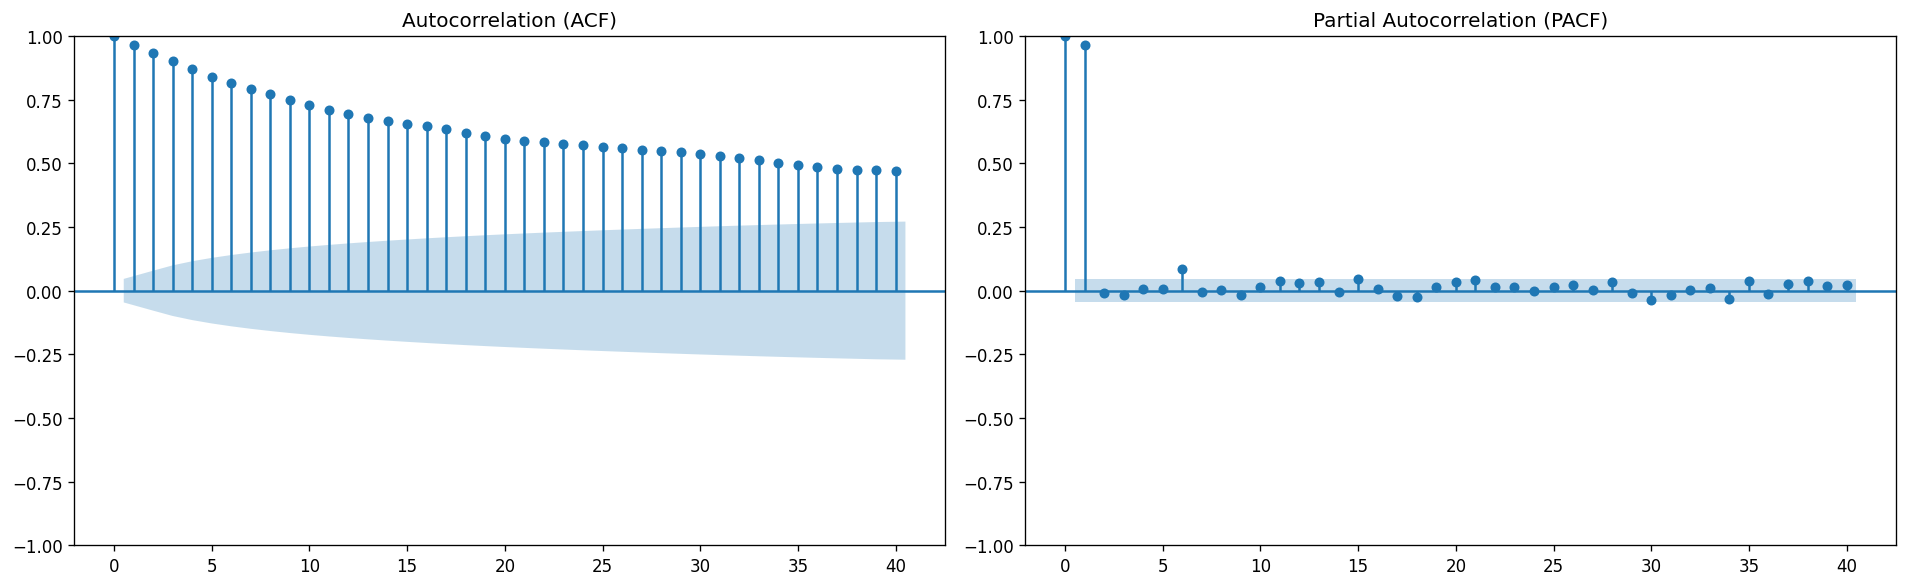

In [ ]:
# -----------------------------
# PLOT ACF AND PACF
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot
plot_acf(series, lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

# PACF Plot
plot_pacf(series, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

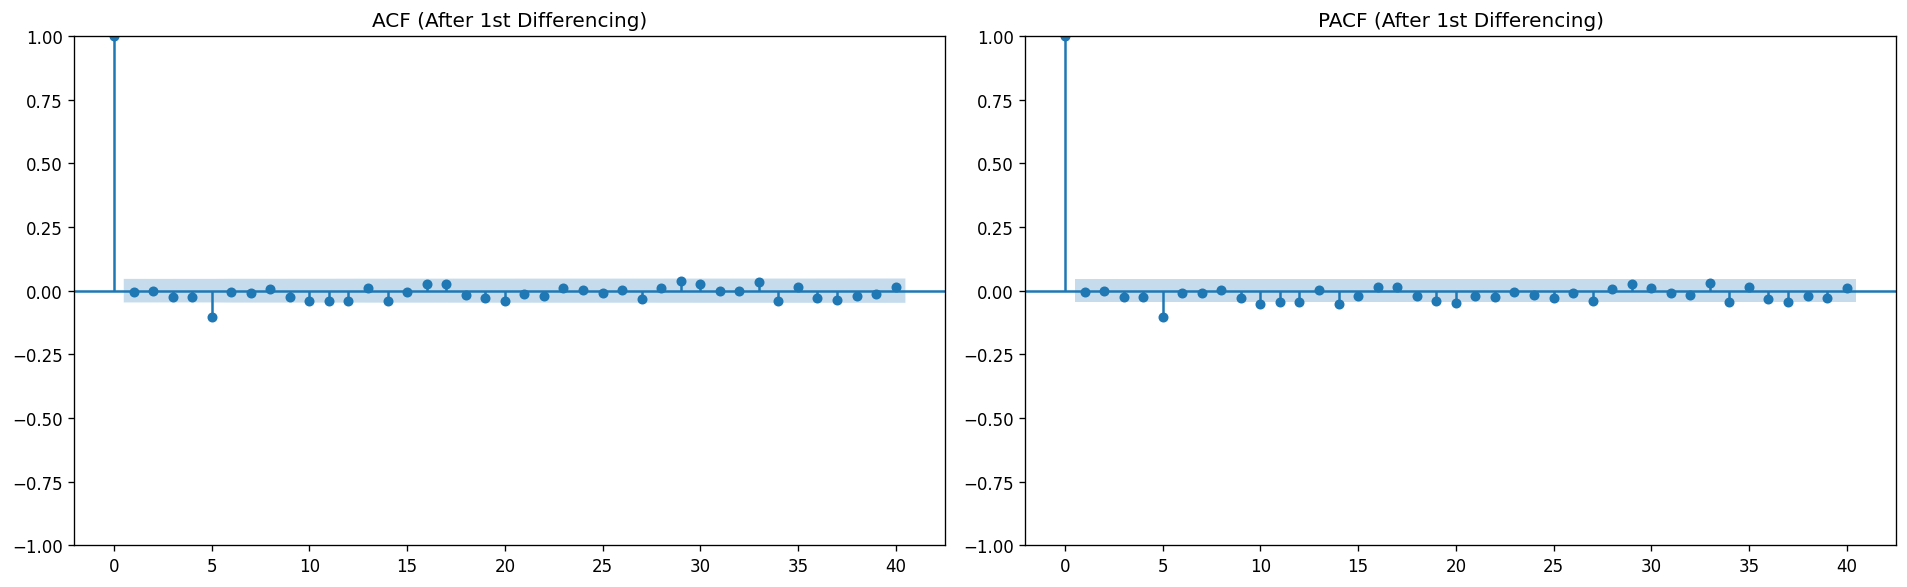

In [ ]:
# -----------------------------
# PLOT ACF AND PACF AFTER FIRST ORDER DIFFERENCING
# -----------------------------

# This calculates the change from one day to the next
series_diff = series.diff().dropna()

# Plotting the results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF Plot of Differenced Data
plot_acf(series_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF (After 1st Differencing)')

# PACF Plot of Differenced Data
plot_pacf(series_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF (After 1st Differencing)')

plt.tight_layout()
plt.show()

The VIX series appears stationary after first differencing ($d=1$), based on both diagnostic plots and unit-root test evidence.

In [ ]:
print("Unit root test summary: Δ VIX")
display(unit_root_summary(series_diff, name="d1_VIX"))

Unit root test summary: Δ VIX


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,d1_VIX,ADF (constant),-14.0212,0.0000,13
1,d1_VIX,KPSS (constant),0.0240,0.1000,22
2,d1_VIX,ADF (constant + trend),-14.0195,0.0000,13
3,d1_VIX,KPSS (constant + trend),0.0216,0.1000,22


### ARIMA Candidate Setup

PACF behavior on the differenced series suggests a compact short-memory structure, so we start with parsimonious ARIMA candidates and then expand to a small comparison grid.

As a baseline, ARIMA(0,1,0) corresponds to a random-walk level forecast.

In [ ]:
# --- candidate ARIMA models (p,1,q) ---
candidates = [
    ("ARIMA(0,1,0)", (0,1,0), None),
    ("ARIMA(1,1,1)", (1,1,1), None),
    ("ARIMA(3,1,3)", (3,1,3), None),
    ("ARIMA(2,1,0)", (2,1,0), None),
    ("ARIMA(0,1,2)", (0,1,2), None),
    ("ARIMA(2,1,2)", (2,1,2), None),
    ("ARIMA(5,1,0)", (5,1,0), None),
    ("ARIMA(0,1,5)", (0,1,5), None),
    ("ARIMA(5,1,5)", (5,1,5), None),
]


# --- fit each candidate ---
fits = {}
rows = []
for name, order, seasonality in candidates:
    m = ARIMA(series, order=order, trend="n").fit()
    fits[name] = (m, order)
    rows.append({
        "model": name,
        "order": order,
        "AIC": m.aic,
        "BIC": m.bic
    })

# --- comparison table sorted by AIC ---
cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/st

,model,order,AIC,BIC
0,"ARIMA(5,1,5)","(5, 1, 5)",6151.5541,6211.9745
1,"ARIMA(2,1,2)","(2, 1, 2)",6157.4010,6184.8648
2,"ARIMA(3,1,3)","(3, 1, 3)",6157.4546,6195.9039
3,"ARIMA(0,1,5)","(0, 1, 5)",6169.5251,6202.4817
4,"ARIMA(5,1,0)","(5, 1, 0)",6172.9125,6205.8691
5,"ARIMA(0,1,0)","(0, 1, 0)",6184.3672,6189.8600
6,"ARIMA(0,1,2)","(0, 1, 2)",6188.3420,6204.8203
7,"ARIMA(2,1,0)","(2, 1, 0)",6188.3428,6204.8211
8,"ARIMA(1,1,1)","(1, 1, 1)",6188.3443,6204.8225


Using the AIC/BIC comparison, **ARIMA(2,1,2)** is selected as the mean model because it provides a strong fit without unnecessary complexity.

### Residual Diagnostics For The Mean Model

We test whether ARIMA residuals are approximately white noise using residual plots, Ljung-Box statistics, and distributional checks.

In [ ]:
best_name = "ARIMA(2,1,2)"
best_fit = fits.get(best_name)[0]

print("\nSelected model by AIC:", best_name)
if best_fit is None:
    raise RuntimeError(f"Best model {best_name} failed to fit.")
print(best_fit.summary())


Selected model by AIC: ARIMA(2,1,2)
                               SARIMAX Results                                
Dep. Variable:                    VIX   No. Observations:                 1796
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -3073.701
Date:                Fri, 17 Apr 2026   AIC                           6157.401
Time:                        02:53:47   BIC                           6184.865
Sample:                    04-18-2021   HQIC                          6167.540
                         - 03-18-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0785      0.290      0.270      0.787      -0.490       0.647
ar.L2          0.8050      0.270      2.979      0.003       0.275       1.335
ma.L1         -

,lb_stat,lb_pvalue
2,2.7528,0.2525
4,2.7596,0.5988
6,12.6408,0.0491
8,13.7298,0.0891


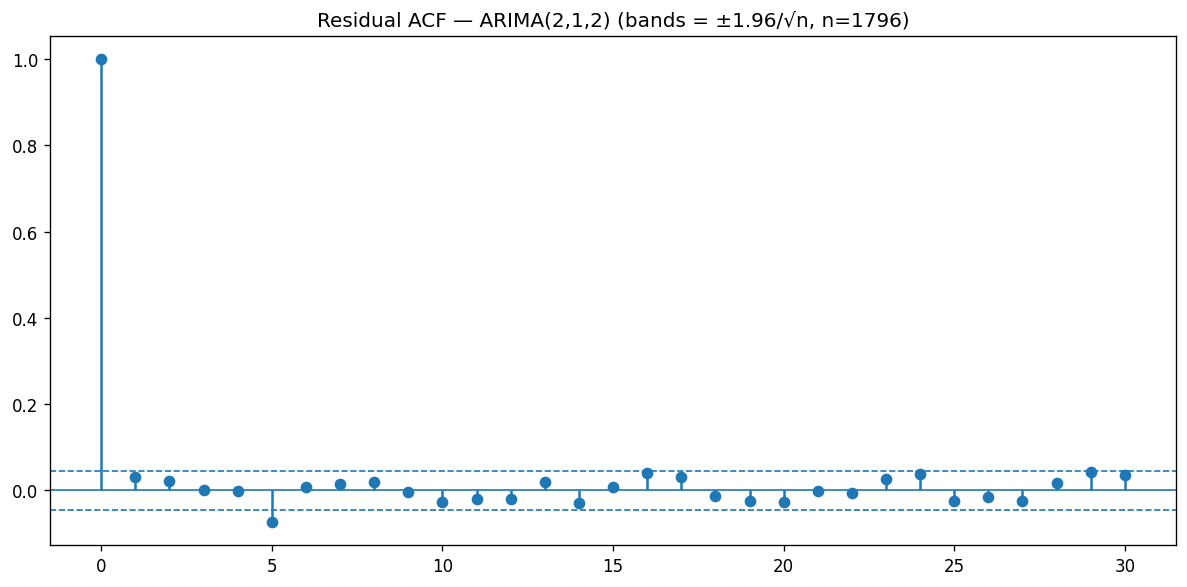

In [ ]:
resid, lb_vix = residual_report(best_fit, lags=(2,4,6,8))
display(lb_vix)
plot_resid_acf(resid, nlags=30, title=f"Residual ACF — {best_name}")

### Holdout Forecasting Setup

A short holdout experiment on the final 6 observed days is used to quantify near-term forecasting error before producing the final Apr 2026 forecast.

In [ ]:
h = 6

# --- split ---
train = series[:-h]
test = series[-h:]

model = ARIMA(train, order=(2,1,2), trend="n").fit()

multi_forecast = model.forecast(steps=h)
forecast = np.asarray(multi_forecast)[:h]

fc_tbl = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast
}, index=test.index)


from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(test.values, forecast)
print(f"Holdout RMSE: {rmse:.6f}")

display(fc_tbl)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Holdout RMSE: 1.671616


,Actual,Forecast
date,,
2026-03-13,27.1900,26.8368
2026-03-14,25.9633,26.4842
2026-03-15,24.7367,26.0915
2026-03-16,23.5100,25.7762
2026-03-17,22.3700,25.4351
2026-03-18,25.0900,25.1540


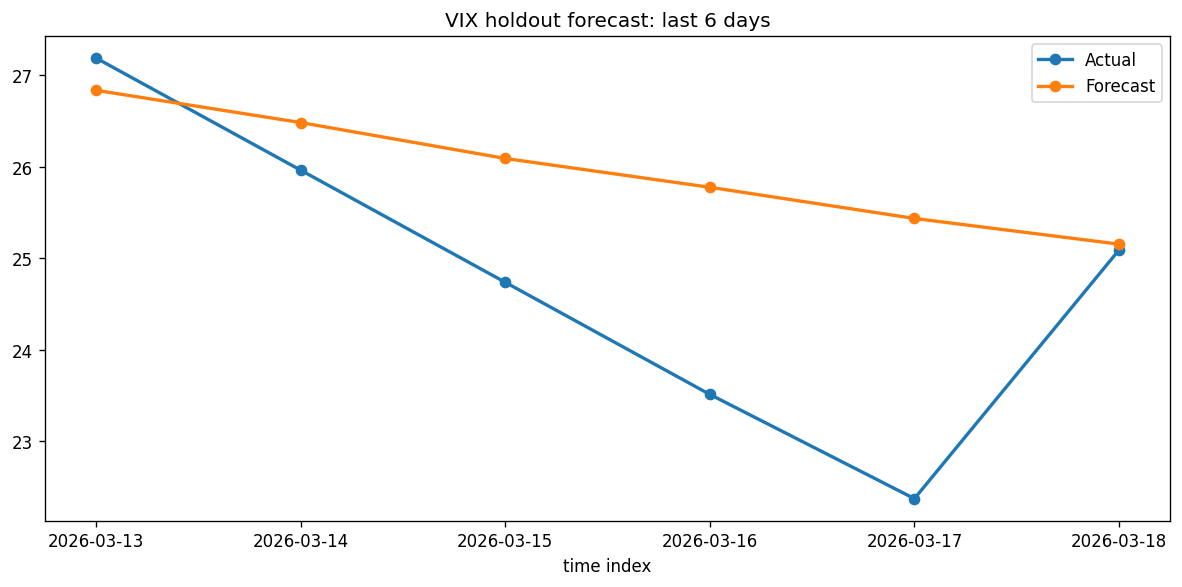

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(fc_tbl.index, fc_tbl["Actual"].values, marker="o", linewidth=2, label="Actual")
plt.plot(fc_tbl.index, fc_tbl["Forecast"].values, marker="o", linewidth=2, label="Forecast")
plt.title("VIX holdout forecast: last 6 days")
plt.xlabel("time index")
plt.tight_layout()
plt.legend()
plt.show()

### ARCH Effect Diagnostics

Next, we test whether residual variance is conditionally heteroskedastic using ARCH-LM evidence and squared-residual autocorrelation plots.

In [ ]:
print("Unit root test summary: VIX level")
display(unit_root_summary(series, name="VIX"))

print("Unit root test summary: first difference (d1_VIX)")
display(unit_root_summary(series_diff, name="d1_VIX"))

Unit root test summary: exchange rate level


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,VIX,ADF (constant),-4.7979,0.0001,5
1,VIX,KPSS (constant),1.2371,0.0100,26
2,VIX,ADF (constant + trend),-4.9739,0.0002,5
3,VIX,KPSS (constant + trend),0.4389,0.0100,26


Unit root test summary: first difference


/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")
/tmp/ipykernel_22073/296369176.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression=reg, nlags="auto")


,series,test,stat,pvalue,usedlag
0,series,ADF (constant),-14.0212,0.0000,13
1,series,KPSS (constant),0.0240,0.1000,22
2,series,ADF (constant + trend),-14.0195,0.0000,13
3,series,KPSS (constant + trend),0.0216,0.1000,22


### Fat-Tail Check

Residual behavior is compared with Gaussian assumptions via histogram, Q-Q analysis, and normality statistics before choosing the volatility innovation distribution.

In [ ]:
arima_res = ARIMA(series, order=(2,1,2), trend="n").fit()
resid = arima_res.resid

resid[:5]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,0
date,
2021-04-18,17.2900
2021-04-19,0.0000
2021-04-20,1.3900
2021-04-21,-1.1242
2021-04-22,1.1925


In [ ]:
from statsmodels.stats.stattools import jarque_bera


jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(resid)

print("JB stat:", jb_stat)
print("JB p-value:", jb_pvalue)
print("JB skew:", jb_skew)
print("JB kurtosis:", jb_kurt)

JB stat: 124942.43937434157
JB p-value: 0.0
JB skew: 1.7818372278914596
JB kurtosis: 43.705155192182175


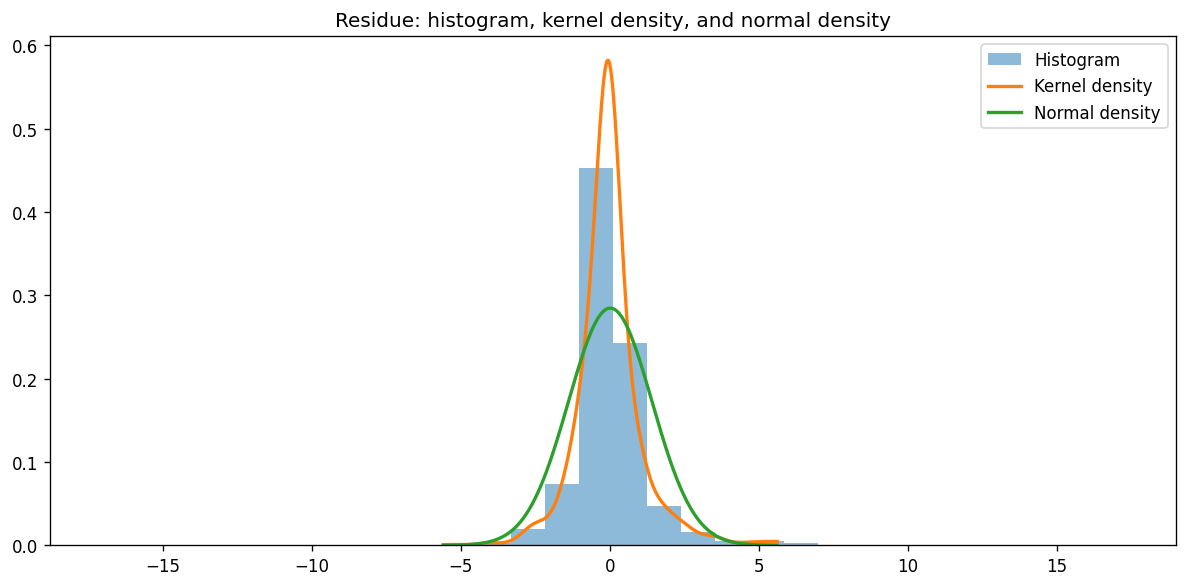

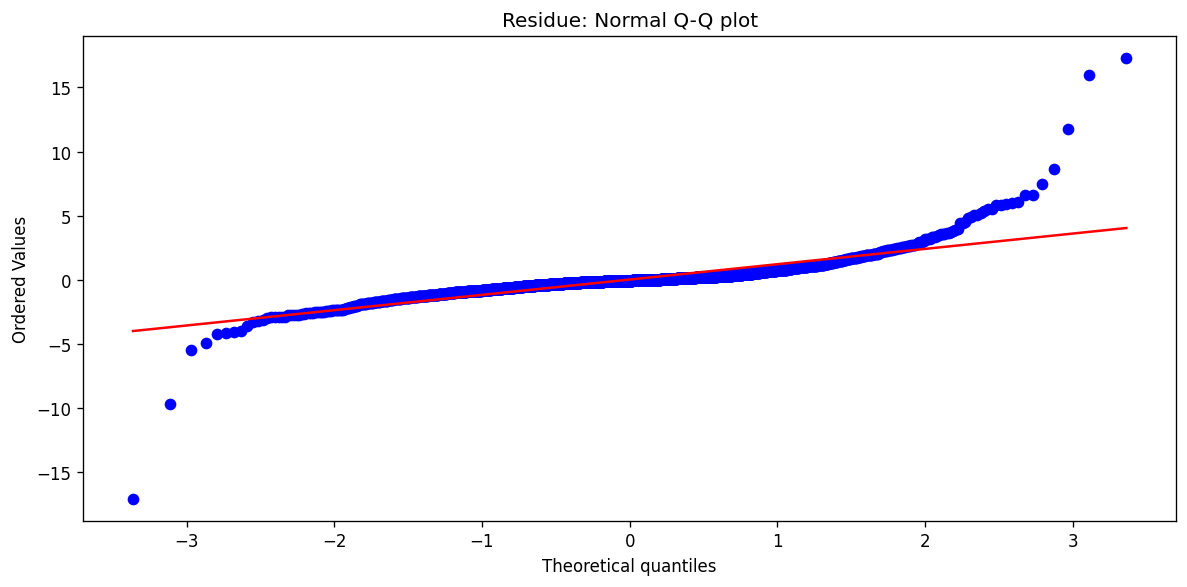

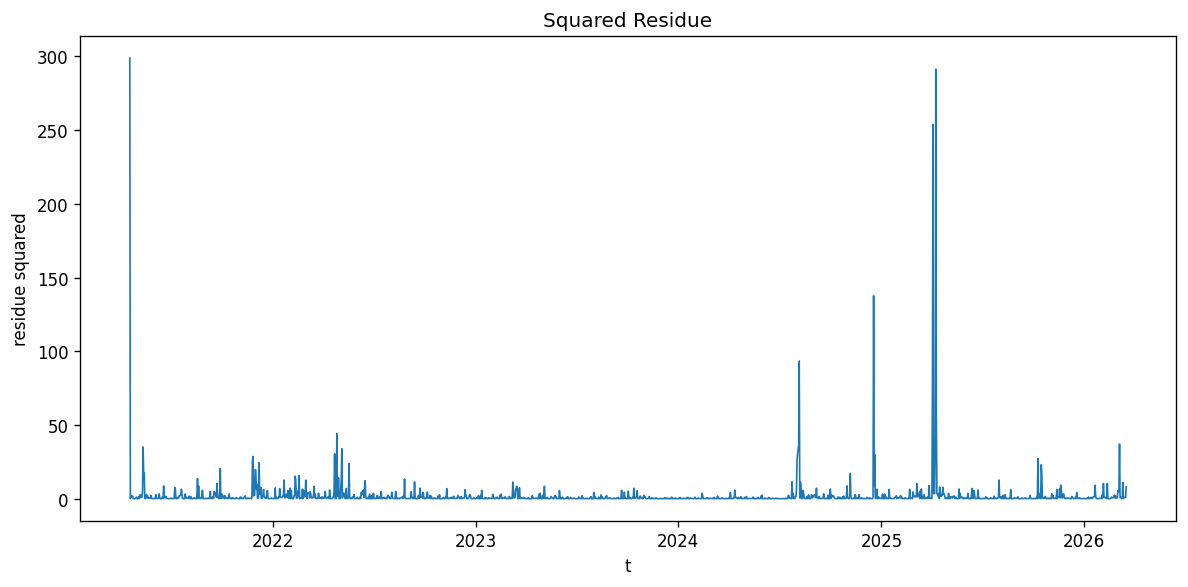

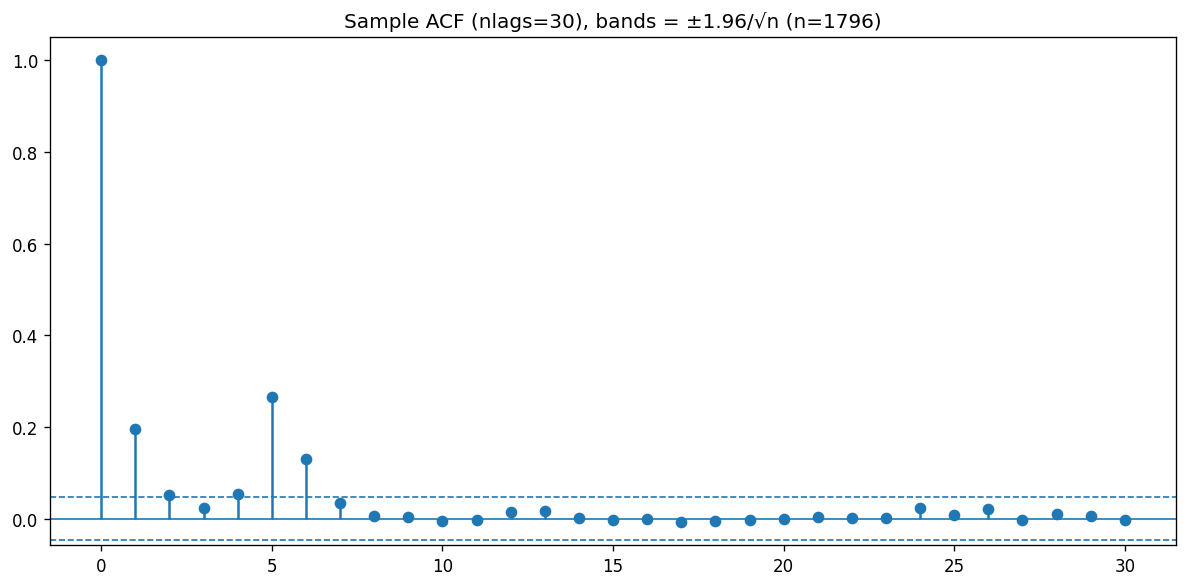

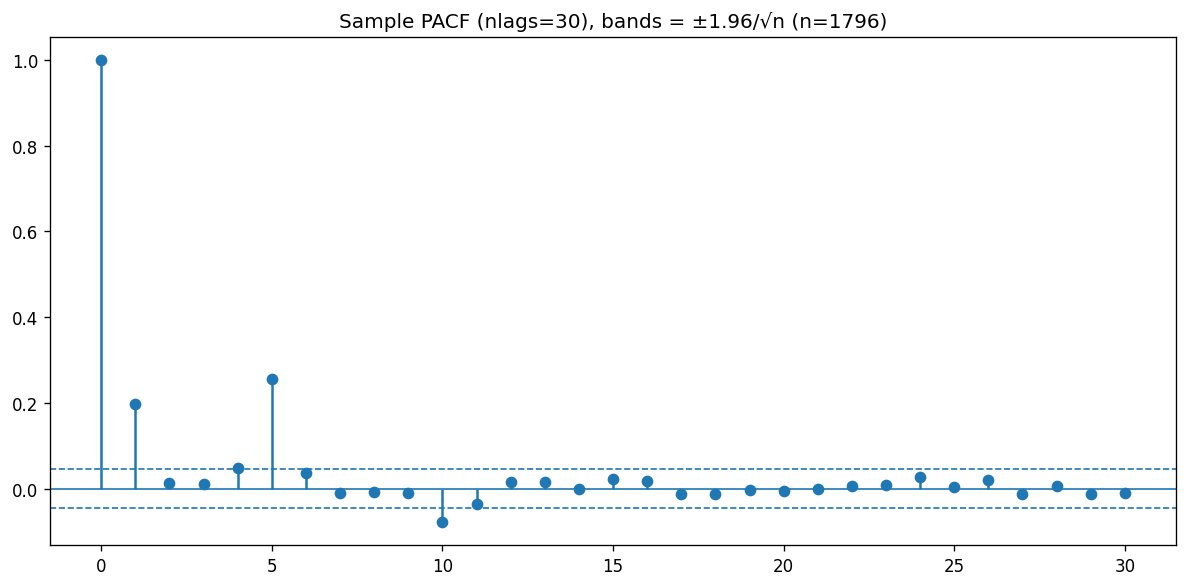

(array([ 1.    ,  0.1961,  0.0512,  0.0224,  0.054 ,  0.2651,  0.1307,
         0.0348,  0.0062,  0.0033, -0.0043, -0.0028,  0.0155,  0.0162,
         0.0011, -0.0024, -0.0012, -0.0079, -0.0046, -0.0027, -0.0019,
         0.0038,  0.0011,  0.0014,  0.0225,  0.0088,  0.0213, -0.0026,
         0.009 ,  0.0058, -0.0022]),
 array([ 1.    ,  0.1961,  0.0132,  0.0103,  0.049 ,  0.2552,  0.0361,
        -0.0112, -0.0071, -0.0117, -0.0787, -0.0355,  0.0154,  0.0154,
        -0.001 ,  0.021 ,  0.0176, -0.0135, -0.0127, -0.0025, -0.0061,
        -0.0017,  0.0054,  0.0092,  0.0278,  0.0029,  0.0202, -0.0135,
         0.0061, -0.0125, -0.0106]))

In [ ]:
plot_hist_density_qq(resid, title_prefix="Residuals")
plot_series(resid**2, "Squared Residuals", ylabel="residual squared")
plot_acf_pacf(resid**2, nlags=30)

In [ ]:
lm_tbl = arch_lm_table(resid**2, nlags=5)
print("--- ARCH-LM on ARIMA residuals ---")
lm_tbl

--- ARCH-LM on ARIMA residuals ---


,LM stat,LM p-value,F stat,F p-value,lags
0,234.5547,0.0000,53.7995,0.0000,5


The ARCH-LM results indicate time-varying volatility, so a GARCH-family variance model is appropriate.

In [ ]:
# Install once if the package is missing in your environment.
%pip install -q arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.2 MB/s eta 0:00:00


In [ ]:
# Candidate GARCH model fitting and comparison
from arch import arch_model

candidates = [
    ("GARCH(1,1)", {"mean": "Zero", "vol": "Garch", "p": 1, "q": 1, "dist": "normal"}),
    ("GARCH(1,1)", {"mean": "Zero", "vol": "Garch", "p": 1, "q": 1, "dist": "t"}),
    ("GARCH(1,1)", {"mean": "Zero", "vol": "Garch", "p": 1, "q": 1, "dist": "skewt"}),
    ("ARCH(5)", {"mean": "Zero", "vol": "ARCH", "p": 5, "dist": "normal"}),
    ("GARCH(5,1)", {"mean": "Zero", "vol": "Garch", "p": 5, "q": 1, "dist": "normal"}),
    ("GARCH(1,2)", {"mean": "Zero", "vol": "Garch", "p": 1, "q": 2, "dist": "normal"}),
    ("GARCH(2,1)", {"mean": "Zero", "vol": "Garch", "p": 2, "q": 1, "dist": "normal"}),
    ("GJR-GARCH(1,1)", {"mean": "Zero", "vol": "GARCH", "p": 1, "o": 1, "q": 1, "dist": "t"}),
    ("EGARCH(1,1)", {"mean": "Zero", "vol": "EGARCH", "p": 1, "q": 1, "dist": "t"}),
]

rows = []
fits = {}

for name, args in candidates:
    am = arch_model(resid, **args)
    res = am.fit(disp="off", show_warning=False)
    fits[name] = res

    rows.append({
        "model": name,
        "dist": args.get("dist"),
        "(p, o, q)": (args.get("p", np.nan), args.get("o", 0), args.get("q", np.nan)),
        "loglik": float(res.loglikelihood),
        "AIC": res.aic,
        "BIC": res.bic,
    })

cmp = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
cmp

,model,dist,"(p, o, q)",loglik,AIC,BIC
0,"GJR-GARCH(1,1)",t,"(1, 1, 1)",-2335.6291,4681.2581,4708.7247
1,"GARCH(1,1)",skewt,"(1, 0, 1)",-2340.8599,4691.7198,4719.1864
2,"GARCH(1,1)",t,"(1, 0, 1)",-2355.1032,4718.2065,4740.1797
3,"EGARCH(1,1)",t,"(1, 0, 1)",-2359.6444,4727.2887,4749.2620
4,"GARCH(5,1)",normal,"(5, 0, 1)",-2669.4622,5352.9245,5391.3777
5,ARCH(5),normal,"(5, 0, nan)",-2684.0112,5380.0225,5412.9824
6,"GARCH(1,2)",normal,"(1, 0, 2)",-2697.7485,5403.4971,5425.4703
7,"GARCH(1,1)",normal,"(1, 0, 1)",-2707.7584,5421.5169,5437.9968
8,"GARCH(2,1)",normal,"(2, 0, 1)",-2707.7584,5423.5169,5445.4902


Based on model comparison and residual behavior, we proceed with **GJR-GARCH(1,1)** and heavy-tailed innovations to capture asymmetric volatility dynamics.

### Standardized Residual Diagnostics

After fitting the volatility model, standardized residuals are re-evaluated for remaining autocorrelation, ARCH effects, and major distributional misspecification.

In [ ]:
am = arch_model(resid, mean="Zero", vol="GARCH", p=1, o=1, q=1, dist="t")
gjr_garch = am.fit(disp="off")

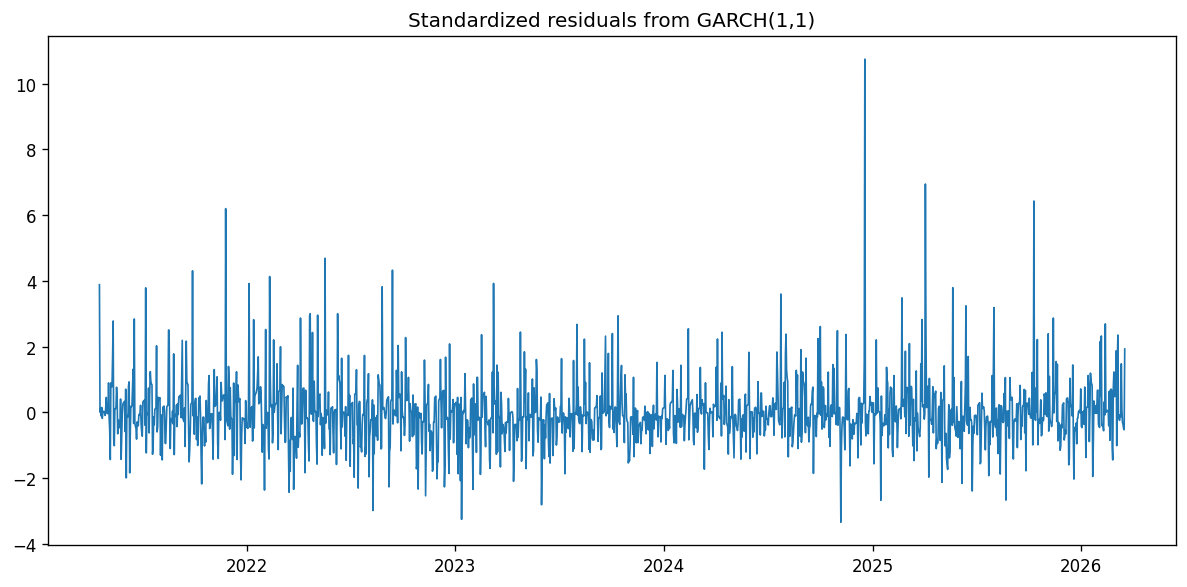

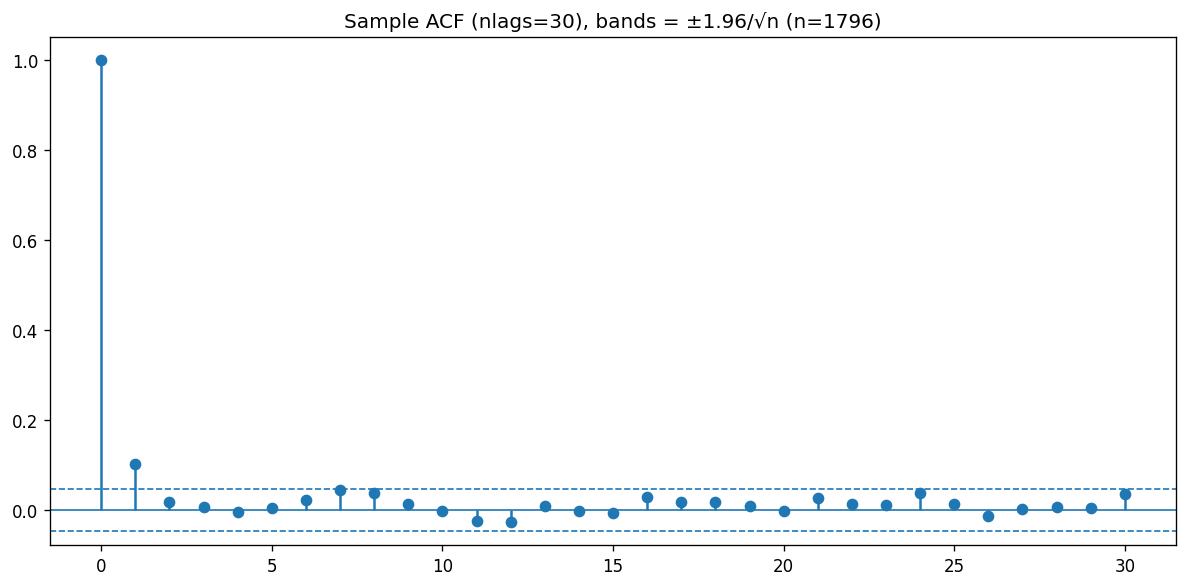

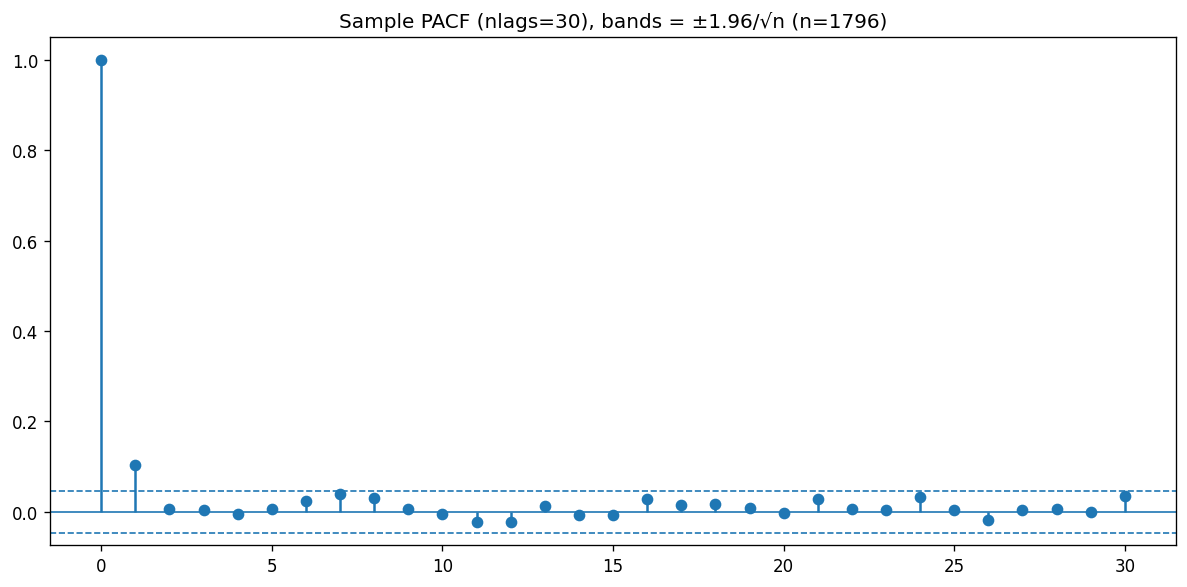

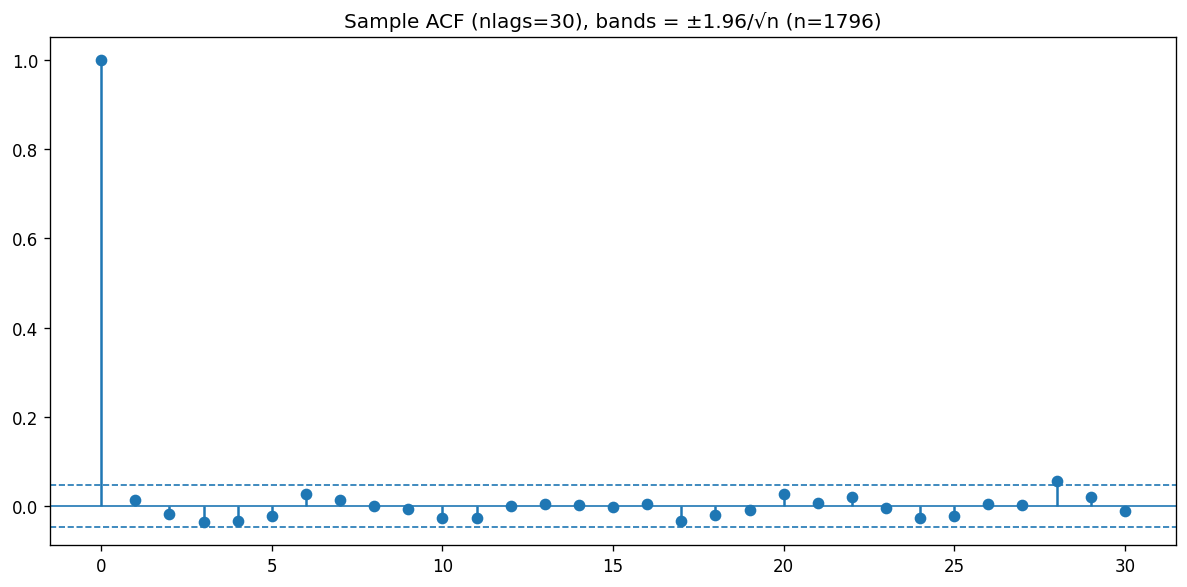

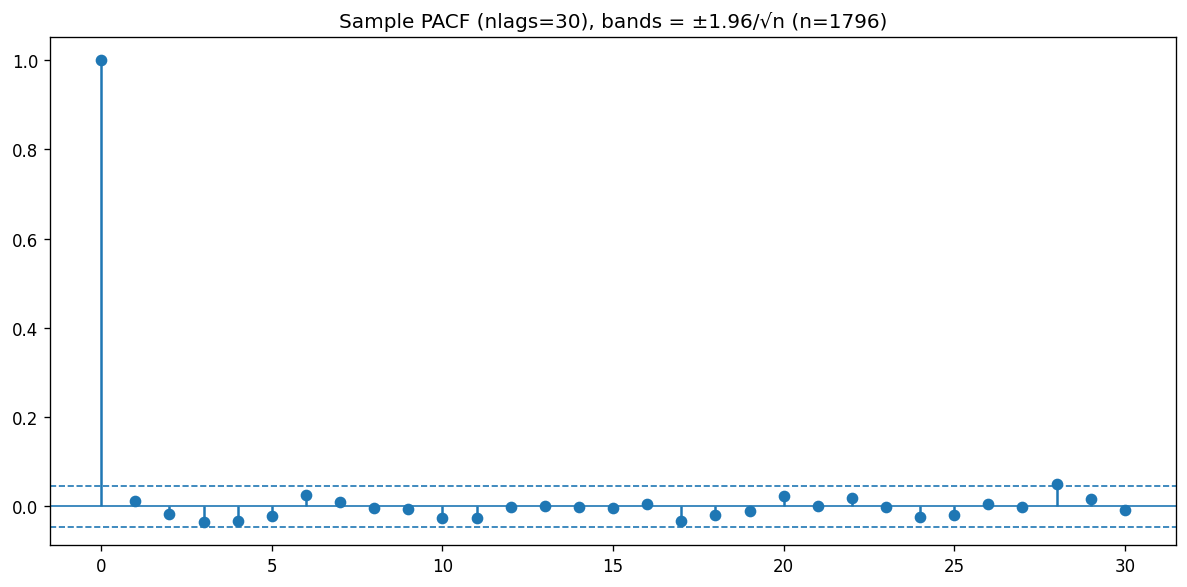

ARCH-LM test on squared standardized residuals


,LM stat,LM p-value,F stat,F p-value,lags
0,5.7986,0.3263,1.1596,0.3268,5


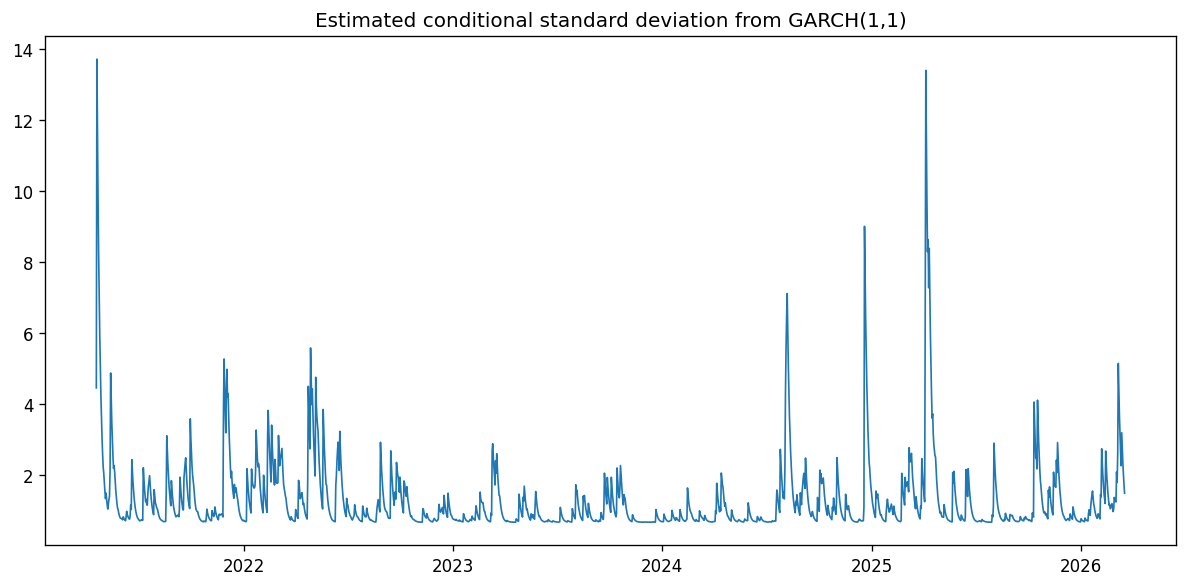

In [ ]:
std_resid = gjr_garch.std_resid
cond_vol = gjr_garch.conditional_volatility.reindex(std_resid.index)

plt.figure(figsize=(10,5))
plt.plot(std_resid, linewidth=1)
plt.title("Standardized residuals from GARCH(1,1)")
plt.tight_layout()
plt.show()

plot_acf_pacf(std_resid, nlags=30)
plot_acf_pacf(std_resid**2, nlags=30)

print("ARCH-LM test on squared standardized residuals")
display(arch_lm_table(std_resid, nlags=5))

plt.figure(figsize=(10,5))
plt.plot(cond_vol.index, cond_vol, linewidth=1)
plt.title("Estimated conditional standard deviation from GARCH(1,1)")
plt.tight_layout()
plt.show()

ARCH-LM evidence on standardized residuals suggests no material remaining ARCH structure, supporting the adequacy of the chosen volatility specification.

### Final VIX Forecast (Apr 20-24, 2026)

This section presents final point forecasts and 95% prediction intervals from the ARIMA(2,1,2) + GJR-GARCH pipeline, refit on the full available sample.

In [ ]:
SPLIT_RATIO = 0.8

# Use the full cleaned series for final train/test split.
series = process_live_df(df_live, "date", TARGET_LABEL)
split_idx = int(len(series) * SPLIT_RATIO)
train = series.iloc[:split_idx]
test = series.iloc[split_idx:]

print(f"Total observations: {len(series)}")
print(f"Training set: {len(train)} days (ends: {train.index[-1].date()})")
print(f"Test set: {len(test)} days (starts: {test.index[0].date()})")

Total Observations: 1826
Training set: 1460 days (Ends: 2025-04-16)
Test set: 366 days (Starts: 2025-04-17)


In [ ]:
import math
from scipy.stats import t
from sklearn.metrics import mean_absolute_error, mean_squared_error


def rolling_arima_gjr_forecast_tqdm(
    train,
    test,
    d=1,
    arima_order=(2, 1, 2),
    garch_p=1,
    garch_o=1,
    garch_q=1,
    dist="t",
    alpha=0.05,
 ):
    preds = []
    lowers = []
    uppers = []
    pred_index = []

    train_current = train.copy()
    test_remaining = test.copy()

    total_blocks = math.ceil(len(test) / d) if d > 0 else 0
    pbar = tqdm(total=total_blocks, unit="block")

    try:
        while len(test_remaining) > 0:
            h = min(d, len(test_remaining))

            arima = SARIMAX(
                train_current,
                order=arima_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            arima_res = arima.fit(disp=False)

            resid = arima_res.resid.dropna()
            am = arch_model(
                resid,
                vol="GARCH",
                p=garch_p,
                o=garch_o,
                q=garch_q,
                dist=dist,
                mean="Zero",
            )
            try:
                am_res = am.fit(disp="off", show_warning=False)
            except Exception:
                # Fallback to a simpler asymmetric-free model if optimization fails.
                am = arch_model(resid, vol="GARCH", p=1, o=0, q=1, dist=dist, mean="Zero")
                am_res = am.fit(disp="off", show_warning=False)

            arima_fore = arima_res.get_forecast(steps=h)
            arima_mean = arima_fore.predicted_mean

            garch_fore = am_res.forecast(horizon=h, reindex=False, method="analytic")
            var_fore = garch_fore.variance.values[-1, :]

            try:
                df_t = float(am_res.params.get("nu", 8.0))
            except Exception:
                df_t = 8.0

            q = t.ppf(1 - alpha / 2, df=df_t)
            se = np.sqrt(var_fore)
            lower = arima_mean - q * se
            upper = arima_mean + q * se

            idx = test_remaining.index[:h]
            preds.extend(arima_mean.values.tolist())
            lowers.extend(lower.tolist())
            uppers.extend(upper.tolist())
            pred_index.extend(idx.tolist())

            pbar.set_description(f"Fitted window size {len(train_current)}; forecasted {h} steps")
            pbar.update(1)

            to_append = test_remaining.iloc[:h]
            train_current = pd.concat([train_current, to_append])
            test_remaining = test_remaining.iloc[h:]

        pbar.close()

    except Exception:
        pbar.close()
        raise

    preds = pd.Series(preds, index=pred_index).sort_index().reindex(test.index)
    lowers = pd.Series(lowers, index=pred_index).sort_index().reindex(test.index)
    uppers = pd.Series(uppers, index=pred_index).sort_index().reindex(test.index)

    actual = test.loc[preds.index]
    mask = actual.notna() & preds.notna()
    y_true = actual[mask].values
    y_pred = preds[mask].values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    with np.errstate(divide="ignore", invalid="ignore"):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))) * 100

    covered = ((y_true >= lowers[mask].values) & (y_true <= uppers[mask].values)).mean()

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE(%)": mape,
        "PI Coverage (1-alpha)": covered,
        "n_forecasts": len(y_true),
    }

    return preds, lowers, uppers, metrics

In [ ]:
preds, lower, upper, metrics = rolling_arima_gjr_forecast_tqdm(train, test, d=5)

# print metrics
for k, v in metrics.items():
    print(f"{k}: {v}")

# show first 10 rows of results
results = pd.DataFrame({
    'actual': test,
    'forecast': preds,
    'lower95': lower,
    'upper95': upper
})
print("\nFirst 10 forecast rows:")
print(results.head(10))

Fitted window size 1565; forecasted 5 steps:  30%|██▉       | 22/74 [00:16<00:30,  1.70block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1575; forecasted 5 steps:  32%|███▏      | 24/74 [00:17<00:31,  1.60block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1585; forecasted 5 steps:  35%|███▌      | 26/74 [00:19<00:30,  1.55block/s]/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
Fitted window size 1600; forecasted 5 steps:  39%

MAE: 1.4245864953713179
RMSE: 2.092752396030852
MAPE(%): 7.22862168423421
PI Coverage (1-alpha): 0.9344262295081968
n_forecasts: 366

First 10 forecast rows:
            actual  forecast  lower95  upper95
date                                          
2025-04-17 29.6500   32.5577  19.4573  45.6581
2025-04-18 30.6925   32.6345  19.5050  45.7641
2025-04-19 31.7350   32.5789  19.4203  45.7374
2025-04-20 32.7775   32.6237  19.4361  45.8112
2025-04-21 33.8200   32.5892  19.3727  45.8057
2025-04-22 30.5700   33.8889  25.8831  41.8947
2025-04-23 28.4500   33.8471  25.7916  41.9026
2025-04-24 26.4700   33.8851  25.7803  41.9900
2025-04-25 24.8400   33.8558  25.7018  42.0097
2025-04-26 24.9433   33.8799  25.6771  42.0827


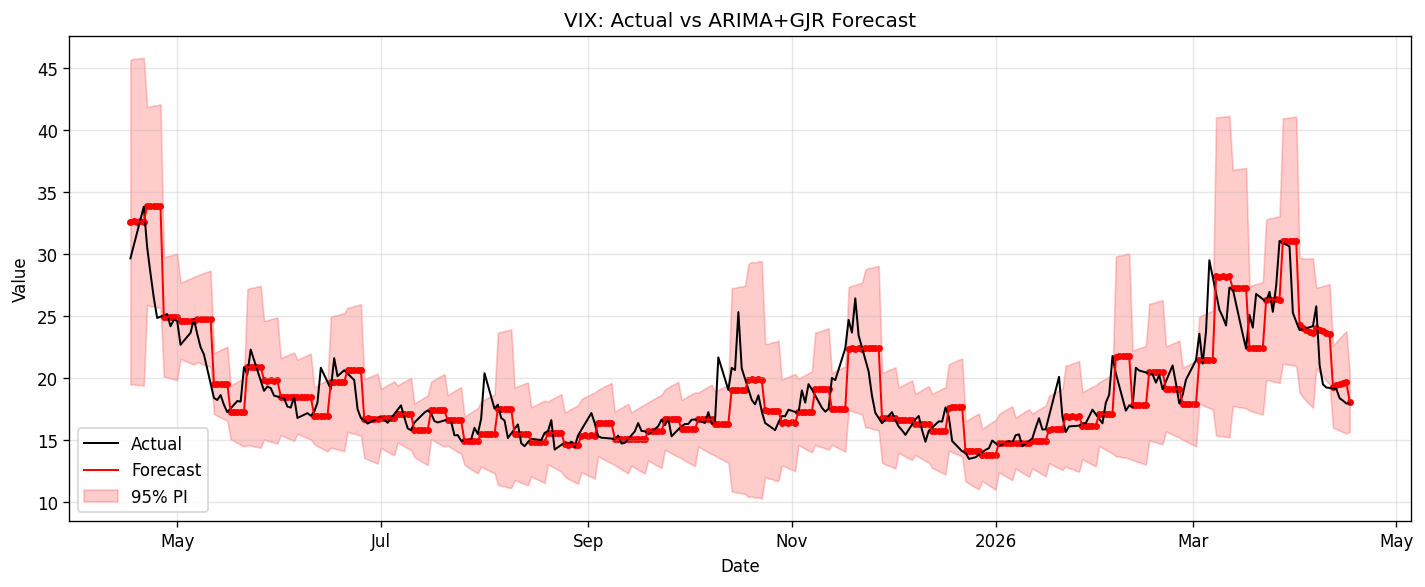

In [ ]:
import matplotlib.dates as mdates


def plot_forecasts(
    actual,
    forecast,
    lower,
    upper,
    title="Actual vs Forecast",
    figsize=(12, 5),
    xlabel="Date",
    ylabel="Value",
):
    df = pd.DataFrame(
        {
            "actual": actual,
            "forecast": forecast,
            "lower": lower,
            "upper": upper,
        }
    ).sort_index().dropna(subset=["forecast"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(df.index, df["actual"], color="black", label="Actual", linewidth=1.2)
    ax.plot(df.index, df["forecast"], color="red", label="Forecast", linewidth=1.2)
    ax.fill_between(df.index, df["lower"], df["upper"], color="red", alpha=0.2, label="95% PI")

    ax.scatter(df.index, df["forecast"], color="red", s=10)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

    if hasattr(df.index, "to_pydatetime"):
        locator = mdates.AutoDateLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    plt.tight_layout()
    plt.show()


plot_forecasts(test, preds, lower, upper, title="VIX: Actual vs ARIMA+GJR Forecast")

In [ ]:
# Reuse global forecast horizon settings.
forecast_dates = FORECAST_DATES
h_forecast = H

# Refit ARIMA on the full series.
arima_final = SARIMAX(
    series,
    order=(2, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
arima_res_final = arima_final.fit(disp=False)

# Fit GJR-GARCH on full ARIMA residuals.
resid_final = arima_res_final.resid.dropna()
am_final = arch_model(resid_final, vol="GARCH", p=1, o=1, q=1, dist="t", mean="Zero")
try:
    am_res_final = am_final.fit(disp="off", show_warning=False)
except Exception:
    am_final = arch_model(resid_final, vol="GARCH", p=1, o=0, q=1, dist="t", mean="Zero")
    am_res_final = am_final.fit(disp="off", show_warning=False)

# Mean and variance forecasts.
arima_fore_final = arima_res_final.get_forecast(steps=h_forecast)
arima_mean_final = arima_fore_final.predicted_mean

garch_fore_final = am_res_final.forecast(horizon=h_forecast, reindex=False, method="analytic")
var_fore_final = garch_fore_final.variance.values[-1, :]

try:
    df_t_final = float(am_res_final.params.get("nu", 8.0))
except Exception:
    df_t_final = 8.0

# Build 95% prediction intervals.
alpha = 0.05
q = t.ppf(1 - alpha / 2, df=df_t_final)
se_final = np.sqrt(var_fore_final)
lower_final = arima_mean_final - q * se_final
upper_final = arima_mean_final + q * se_final

# Assemble and print final forecast table.
forecast_results = pd.DataFrame(
    {
        "date": forecast_dates,
        "forecast": arima_mean_final.values,
        "lower95": lower_final.values,
        "upper95": upper_final.values,
    }
).set_index("date")

print("=" * 60)
print(f"VIX Forecast for {FORECAST_START} to {FORECAST_END}")
print("=" * 60)
pd.options.display.float_format = "{:.4f}".format
print(forecast_results)
print("=" * 60)

VIX Forecast for 2026-04-20 to 2026-04-24
            forecast  lower95  upper95
date                                  
2026-04-20   18.0915  15.6947  20.4883
2026-04-21   18.2362  15.5261  20.9463
2026-04-22   18.3706  15.3798  21.3614
2026-04-23   18.4959  15.2486  21.7432
2026-04-24   18.6126  15.1276  22.0976


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
